In [30]:
import autograd.numpy as np  # Import wrapped NumPy from autograd
from autograd import grad    # Import grad function to compute gradients
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

n = 100
m = 50
A = np.random.uniform(-10, 2, (m,n))
At = A.transpose()
K = np.random.uniform(-10, 2, (m,n)).transpose()

true_x = np.random.rand(n,n)
y = A@true_x

def f(x):
    return 0.5 * np.linalg.norm(A@x-y)**2

# Compute the gradient of f using autograd
grad_f_autodiff = grad(f)

def mm_grad_f(K, x):
    return K@(A@x - y)

def grad_f(x):
    return At@(A@x - y)

# Nuclear norm lmo
def lmo(gradient, rad):
    # Compute the leading singular vectors of gradient
    u1, sigma, vt1 = svds(gradient, k=1, which='LM')
    return -rad*(u1 @ vt1)

iterations = range(3000)

x = np.zeros((n,n))
objective_values = []
fw_gaps = []

t = 0.1

Kclose = (1-t)*At + t*K

radius = 100

for i in tqdm(iterations, desc='Optimizing', unit='iteration'):
    step_size = 1./(i+1)
    #closeness = 1./(i+1)
    #Kclose = (1-closeness)*At + closeness*K
    gradient = mm_grad_f(Kclose, x)
    #gradient = grad_f(x)
    s = lmo(gradient, 100)
    real_s = lmo(grad_f(x), 100)
    # Compute the FW gap
    fw_gap = (grad_f(x) * (x - real_s)).sum()
    #fw_gap = (gradient * (x-s)).sum()
    # Store the FW gap
    fw_gaps.append(fw_gap)
    x = x + step_size*(s-x)
    objective_values.append(f(x))

Optimizing:   0%|          | 0/3000 [00:00<?, ?iteration/s]

8.277788581171896


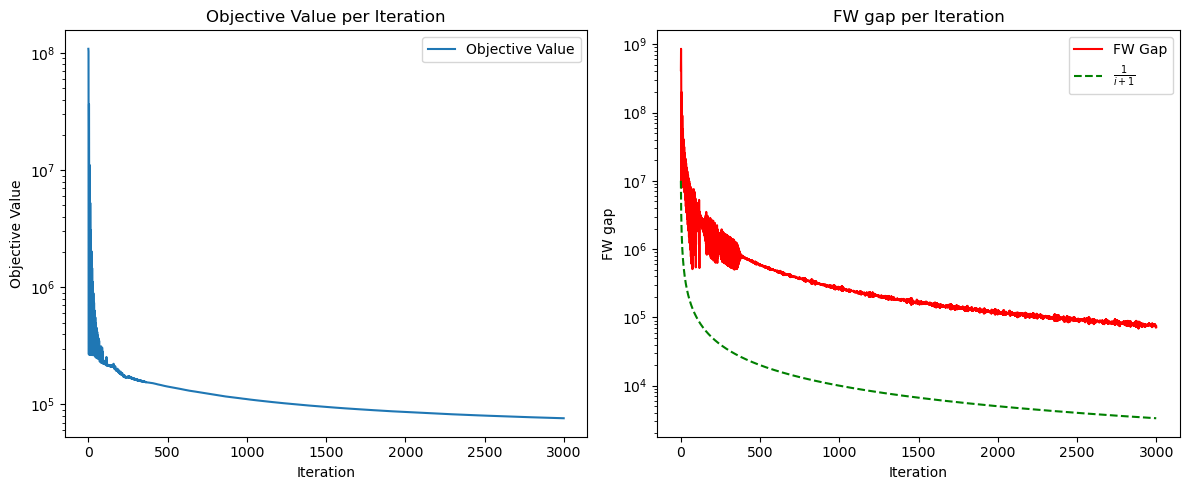

In [31]:
print(np.linalg.norm(Kclose-At, ord=2))

# Compute the theoretical convergence rate
theoretical_rate = [1e7/(i+1) for i in iterations]

# Create a figure with a 1x2 grid of subplots
plt.figure(figsize=(12, 5))

# Plotting the original objective values
plt.subplot(1, 2, 1)
#plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.plot(iterations, objective_values, label='Objective Value')
plt.yscale('log')
plt.title('Objective Value per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.legend()

# Plotting the original FW gaps
plt.subplot(1, 2, 2)
plt.plot(iterations, fw_gaps, color='r', label='FW Gap')
plt.plot(iterations, theoretical_rate, linestyle='--', color='g', label=r'$\frac{1}{i+1}$')
plt.yscale('log')
plt.title('FW gap per Iteration')
plt.xlabel('Iteration')
plt.ylabel('FW gap')
plt.legend()

plt.tight_layout()
plt.show()

Getting global max:   0%|          | 0/180 [00:00<?, ?iteration/s]

0.008379888268156424
0.01
0.011620111731843576
0.01324022346368715
0.014860335195530726
0.0164804469273743
0.018100558659217877
0.01972067039106145
0.02134078212290503
0.0229608938547486
0.02458100558659218
0.026201117318435753
0.027821229050279332
0.029441340782122905
0.031061452513966477
0.032681564245810056
0.03430167597765363
0.03592178770949721
0.03754189944134078
0.03916201117318436
0.04078212290502793
0.04240223463687151
0.04402234636871508
0.04564245810055866
0.047262569832402235
0.04888268156424581
0.05050279329608938
0.05212290502793296
0.05374301675977653
0.05536312849162011
0.05698324022346369
0.05860335195530726
0.06022346368715084
0.06184357541899441
0.06346368715083799
0.06508379888268156
0.06670391061452513
0.06832402234636871
0.06994413407821228
0.07156424581005587
0.07318435754189943
0.07480446927374301
0.07642458100558658
0.07804469273743016
0.07966480446927374
0.08128491620111732
0.08290502793296088
0.08452513966480446
0.08614525139664804
0.0877653631284916
0.089385

Saving figures:   0%|          | 0/180 [00:00<?, ?iteration/s]

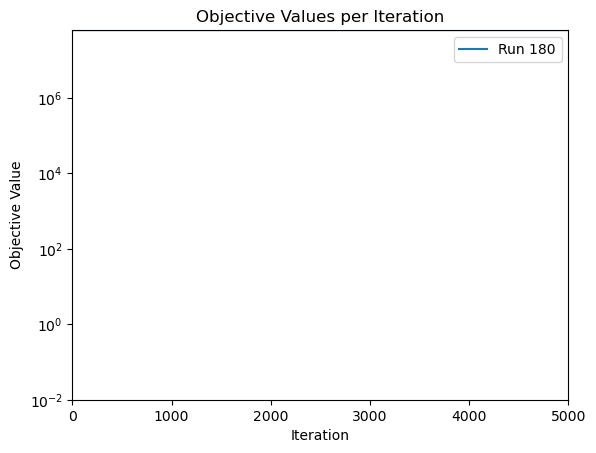

In [3]:
def run_frank_wolfe(Kclose):
    objective_values = []
    x = np.zeros((n,n))
    for i in range(num_iterations):
        step_size = 1./(i+1)
        #closeness = 1./(i+1)
        #Kclose = (1-closeness)*At + closeness*K
        gradient = mm_grad_f(Kclose, x)
        #gradient = grad_f(x)
        s = lmo(gradient, 10)
        real_s = lmo(grad_f(x), 10)
        # Compute the FW gap
        fw_gap = (grad_f(x) * (x - real_s)).sum()
        #fw_gap = (gradient * (x-s)).sum()
        # Store the FW gap
        fw_gaps.append(fw_gap)
        x = x + step_size*(s-x)
        objective_values.append(f(x))
    return objective_values
    

# Setup: Number of iterations, matrices, etc.
num_iterations = 5000
num_matrices = 180

# Create a figure and axis
fig, ax = plt.subplots()


# Example: Determine the global maximum objective value for consistent y-axis
global_max = 0
for i in tqdm(range(num_matrices), desc='Getting global max', unit='iteration'):
    t = 0.01 + (0.3 - 0.01) * (i - 1) / (num_matrices - 1)
    print(t)
    
    # Generate or select your matrix Kclose here
    # Example: Kclose = np.random.randn(*desired_shape)
    Kclose = (1-t)*At + t*K
    
    # Run the algorithm and get objective values
    objective_values = run_frank_wolfe(Kclose)
    
    # Update global_max if needed
    current_max = np.max(objective_values)
    if current_max > global_max:
        global_max = current_max
        
# Example: Run Frank-Wolfe for different matrices and plot
for i in tqdm(range(num_matrices), desc='Saving figures', unit='iteration'):
    # Generate or select your matrix Kclose here
    t = 0.01 + (0.3 - 0.01) * (i - 1) / (num_matrices - 1)
    
    # Run the algorithm and get objective values
    objective_values = run_frank_wolfe(Kclose)
    
    # Plot
    ax.clear()  # Clear previous plots
    ax.plot(objective_values, label=f'Run {i+1}')
    
    # Customize your plot: labels, title, legend, etc.
    ax.set_title('Objective Values per Iteration')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Objective Value')
    ax.set_yscale('log')
    ax.legend()
    
    # Ensure the plots are consistent in terms of scale
    ax.set_xlim([0, num_iterations])
    ax.set_ylim([1e-2, global_max])
    
    # Save the plot as an image file
    plt.savefig(f'mm_fw_plots/plot_{i}.png')


In [4]:
import imageio

num_matrices = 180  # or however many images you have
image_files = [f"mm_fw_plots/plot_{i}.png" for i in range(num_matrices)]  # adjust path and file naming as per your saved files

# Create a writer object
writer = imageio.get_writer("mm_fw_plots/animation.mp4", fps=15)

# Add frames to the animation
for image_file in image_files:
    image = imageio.imread(image_file)
    writer.append_data(image)

# Close the writer to save the video
writer.close()


/var/folders/qd/1dym2wmj2ld6rqz340plb2nr0000gn/T/ipykernel_34776/3767323509.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning dissapear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_file)
/var/folders/qd/1dym2wmj2ld6rqz340plb2nr0000gn/T/ipykernel_34776/3767323509.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning dissapear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_file)
